# K-nearest neighbours con K-means clustering

## Importación de librerías, paquetes y definición de constantes

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# Split para modelado
from sklearn.model_selection import train_test_split
# To save models
import json
import pickle
# Modelado
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn import tree
# Métricas
from utils import get_classifier_metrics
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
# Optimizar
from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.model_selection import RandomizedSearchCV


## Generamos los conjuntos de train y test

In [2]:
X_train = pd.read_csv("../data/processed/xtrain-k-means.csv")
y_train = pd.read_csv("../data/processed/ytrain-k-means.csv")
X_test =  pd.read_csv("../data/processed/xtest-k-means.csv")
y_test =  pd.read_csv("../data/processed/ytest-k-means.csv")

X_train

,Latitude,Longitude,MedInc
0,0.907407,-0.654354,-0.031241
1,-0.042328,0.221636,-0.489988
2,-0.018519,0.050132,0.628208
3,-0.079365,0.047493,0.242081
4,1.547619,-0.970976,-0.809230
...,...,...,...
16507,-0.050265,0.118734,-0.538432
16508,0.552910,-0.245383,-0.857995
16509,-0.354497,0.356201,0.128082
16510,0.867725,-0.918206,0.540725


## Modelado y Ajuste

In [3]:
knn_model = KNeighborsClassifier()
knn_model.fit(X_train, y_train)

C:\Users\Simón\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\neighbors\_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)


,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [4]:
y_pred_test = knn_model.predict(X_test)

In [5]:
y_pred_train = knn_model.predict(X_train)

## Métricas

In [6]:
accuracy_score(y_test, y_pred_test)

0.9903100775193798

In [7]:
print(classification_report(y_test, y_pred_test))

              precision    recall  f1-score   support

           0       0.99      1.00      0.99       913
           1       0.99      0.99      0.99       443
           2       0.99      0.99      0.99       610
           3       0.99      0.98      0.99       988
           4       0.99      0.99      0.99       113
           5       0.99      0.99      0.99      1061

    accuracy                           0.99      4128
   macro avg       0.99      0.99      0.99      4128
weighted avg       0.99      0.99      0.99      4128



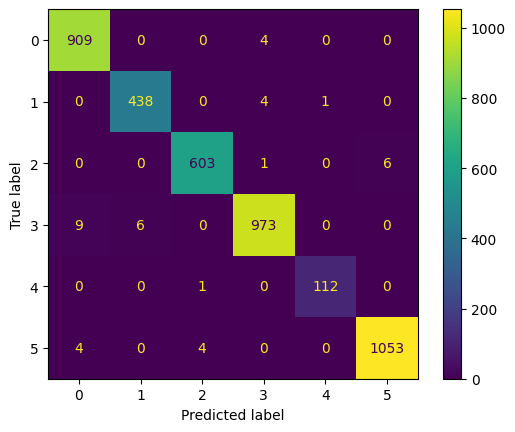

In [8]:
cm = confusion_matrix(y_test, y_pred_test)
ConfusionMatrixDisplay(cm).plot()
plt.show()

## Probamos con `RandomForest` para comparar resultados con otro modelo

### Generación del modelo y ajuste

In [9]:
rf_classifier_model = RandomForestClassifier(random_state = 24)
rf_classifier_model.fit(X_train, y_train)

C:\Users\Simón\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\base.py:1363: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


#### Visualización de los árboles de decisión

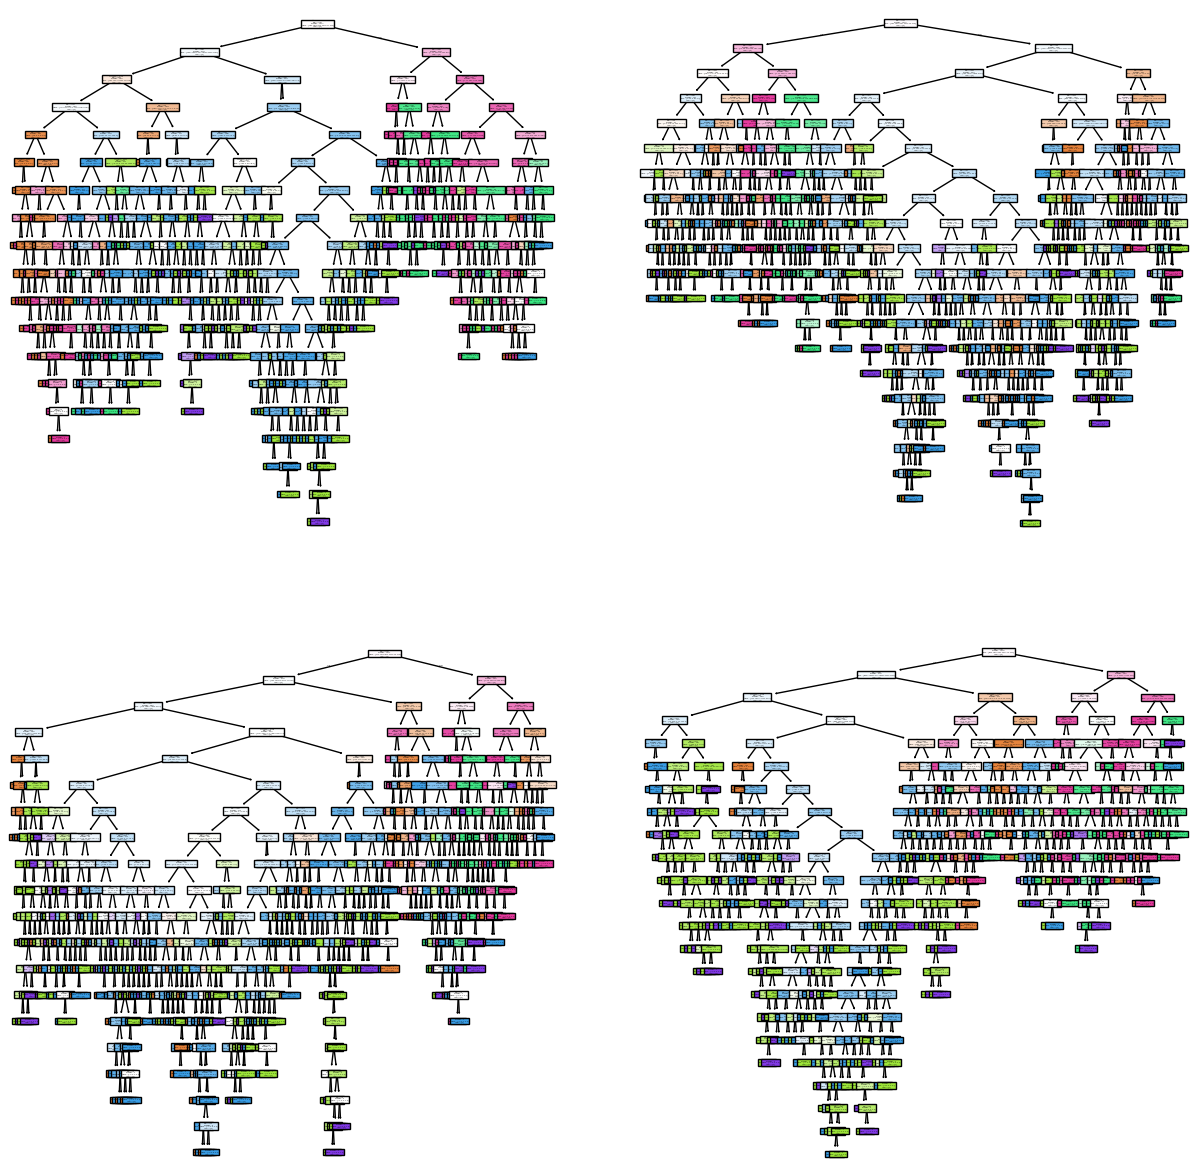

In [10]:
fig, axis = plt.subplots(2, 2, figsize = (15, 15))
tree.plot_tree(rf_classifier_model.estimators_[0], ax = axis[0, 0], feature_names = list(X_train.columns), class_names = True, filled = True)
tree.plot_tree(rf_classifier_model.estimators_[1], ax = axis[0, 1], feature_names = list(X_train.columns), class_names = True, filled = True)
tree.plot_tree(rf_classifier_model.estimators_[2], ax = axis[1, 0], feature_names = list(X_train.columns), class_names = True, filled = True)
tree.plot_tree(rf_classifier_model.estimators_[3], ax = axis[1, 1], feature_names = list(X_train.columns), class_names = True, filled = True)
plt.show()

#### Predicción 

In [11]:
y_pred_test_forest = rf_classifier_model.predict(X_test)

In [12]:
y_pred_train_forest = rf_classifier_model.predict(X_train)


### Métricas

In [13]:
accuracy_score(y_test, y_pred_test_forest)

0.9963662790697675

In [14]:
print(classification_report(y_test, y_pred_test_forest))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       913
           1       1.00      1.00      1.00       443
           2       1.00      1.00      1.00       610
           3       1.00      0.99      0.99       988
           4       1.00      0.99      1.00       113
           5       1.00      1.00      1.00      1061

    accuracy                           1.00      4128
   macro avg       1.00      1.00      1.00      4128
weighted avg       1.00      1.00      1.00      4128



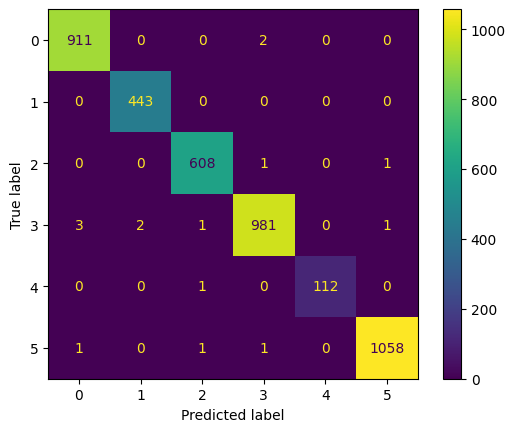

In [15]:
cm = confusion_matrix(y_test, y_pred_test_forest)
ConfusionMatrixDisplay(cm).plot()
plt.show()

## Conclusiones

>- Parece que al hacer clustering, el resultado del modelo es casi perfecto
>- Obtenemos resultado parecidos en ambos modelos pero con RandomForest es ligeramente superior
>- Podemos decir que el clustering ha sido un éxito y tenemos una precisión muy alta en los modelos
>- Considero que no es necesario optimizar porque el rendimiento es bastante alto

## Guardado de modelos

In [16]:
models ={'knn-kmeans-model': knn_model,
         'rf-kmeans-model': rf_classifier_model
        }
with open('C:/Users/Simón/sayons-intro-ml-new/models/modelos-knn-kmeans.pkl', 'wb') as file:
    pickle.dump(models, file)